In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("GOOGL.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,50.050049,52.082081,48.028027,50.220219,50.220219,44659096
1,2004-08-20,50.555557,54.594597,50.300301,54.209209,54.209209,22834343
2,2004-08-23,55.430431,56.796799,54.579578,54.754753,54.754753,18256126
3,2004-08-24,55.675674,55.855858,51.836838,52.487488,52.487488,15247337
4,2004-08-25,52.532532,54.054054,51.991993,53.053055,53.053055,9188602
...,...,...,...,...,...,...,...
4426,2022-03-18,2668.489990,2724.879883,2645.169922,2722.510010,2722.510010,2223100
4427,2022-03-21,2723.270020,2741.000000,2681.850098,2722.030029,2722.030029,1341600
4428,2022-03-22,2722.030029,2821.000000,2722.030029,2797.360107,2797.360107,1774800
4429,2022-03-23,2774.050049,2791.770020,2756.699951,2765.510010,2765.510010,1257700


In [4]:
display(df.shape)
df.dropna()
display(df.shape)

(4431, 7)

(4431, 7)

In [5]:
training_set = df[['Open']]
scaler = MinMaxScaler()
training_set_scaled = scaler.fit_transform(training_set)
training_set_scaled

array([[1.36253641e-04],
       [3.06152003e-04],
       [1.94456941e-03],
       ...,
       [8.98173517e-01],
       [9.15657150e-01],
       [9.19001272e-01]])

In [6]:
X_train = []
X_test =[]
y_train = []
y_test = []

for i in range(60, len(training_set_scaled)-320):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

for i in range(len(training_set_scaled)-320, len(training_set_scaled)):
    X_test.append(training_set_scaled[i-60:i, 0])
    y_test.append(training_set_scaled[i, 0])

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [7]:

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape = (X_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(units=1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [10]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32
)

Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - loss: 0.0020
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 53ms/step - loss: 5.0136e-04
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - loss: 4.2712e-04
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 3.7776e-04
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - loss: 3.5520e-04
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - loss: 3.2322e-04
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 52ms/step - loss: 3.0660e-04
Epoch 8/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 54ms/step - loss: 2.7562e-04
Epoch 9/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - loss: 3.0064e-04
Epoch 10/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - loss: 2.4415e-04
Epoch 11/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - loss: 2.5423e-04
Epoch 12/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - loss: 2.6608e-04
Epoch 13/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 2.3670e-04
Epoch 14/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - lo

In [11]:
y_pred = model.predict(X_test)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [12]:
real_predictions = scaler.inverse_transform(y_pred)
real_actuals = scaler.inverse_transform(y_test.reshape(-1, 1))

print(f"Predicted Price: ${real_predictions[2][0]}")
print(f"Actual Price: ${real_actuals[2][0]}")
print(f"Difference: ${real_predictions[2][0] - real_actuals[2][0]}")

Predicted Price: $1787.0770263671875
Actual Price: $1746.170044
Difference: $40.90698236718754


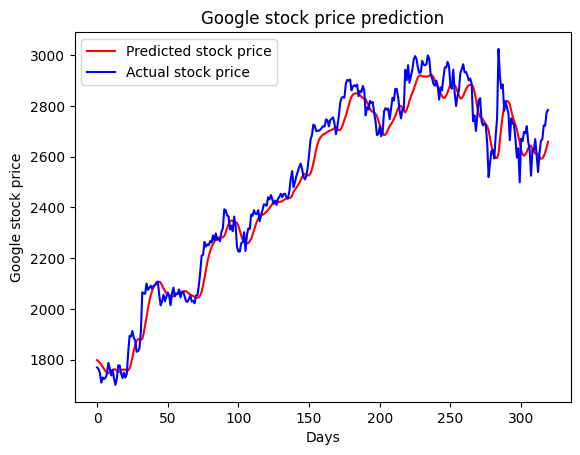

In [13]:
plt.plot(
    real_predictions,
    color='red',
    label='Predicted stock price'
)
plt.plot(
    real_actuals,
    color='blue',
    label='Actual stock price'
)
plt.title('Google stock price prediction')
plt.xlabel('Days')
plt.ylabel('Google stock price')
plt.legend()
plt.show()

In [ ]:
"""# Recurrent Neural Network (RNN) for Google Stock Price Prediction

This practical focuses on:

> Time Series Analysis and Prediction using Recurrent Neural Network (RNN)

using:

> Google Stock Price Dataset

---

# What is Time Series Data?

Time series data is:

> Data collected over time intervals.

Examples:

* stock prices
* weather data
* temperature records
* sales forecasting

---

# Example of Time Series

```text id="rnn1"
Day 1 → 100
Day 2 → 105
Day 3 → 110
```

Data depends on previous values.

---

# What is Time Series Prediction?

Predicting future values using past historical data.

Example:

```text id="rnn2"
Past stock prices → Predict tomorrow's stock price
```

---

# Why Traditional Neural Networks Fail?

Traditional neural networks:

* do not remember previous inputs
* cannot handle sequential dependencies properly

Stock prices depend on:

* previous days
* trends
* patterns over time

---

# What is RNN?

A Recurrent Neural Network (RNN) is a type of deep learning model designed for:

* sequential data
* time series
* language processing

RNN has:

> Memory of previous inputs.

---

# RNN Working

Unlike normal neural networks:

RNN passes information from previous step to next step.

```text id="rnn3"
Previous State → Current State → Next State
```

---

# RNN Formula

h_t=f(Wx_t+Uh_{t-1}+b)

Where:

* ( x_t ) = current input
* ( h_{t-1} ) = previous hidden state
* ( h_t ) = current hidden state

---

# Why RNN for Stock Prediction?

Stock prices are sequential.

Current price depends on:

* previous prices
* historical trends

RNN learns these temporal patterns.

---

# Google Stock Price Dataset

Dataset contains:

* opening price
* closing price
* highest price
* lowest price
* volume

over multiple days.

---

# Workflow of Stock Prediction System

1. Load stock dataset
2. Preprocess data
3. Normalize values
4. Create sequences
5. Build RNN model
6. Train model
7. Predict stock prices

---

# Stock Price Trend Example

---

# Data Preprocessing

Raw stock data must be processed before training.

Steps:

* remove missing values
* normalize data
* create training sequences

---

# Feature Scaling

Scaling improves RNN training.

Most common:

## Min-Max Normalization

x'=\frac{x-x_{min}}{x_{max}-x_{min}}

Converts values between:

```text id="rnn4"
0 and 1
```

---

# Sequence Creation

RNN needs sequential input.

Example:

```text id="rnn5"
Input: [100,105,103]
Output: 110
```

Past prices predict next price.

---

# Sliding Window Technique

Used to generate sequences.

Example window size:

```text id="rnn6"
60 previous days
```

used to predict next day price.

---

# RNN Architecture

```text id="rnn7"
Input Sequence → RNN Layers → Dense Layer → Predicted Price
```

---

# Simple RNN Layer

Example:

```python id="rnn8"
SimpleRNN(50)
```

50 neurons in recurrent layer.

---

# Hidden State

Stores memory from previous time step.

Helps model learn temporal dependencies.

---

# Activation Function

Common activation:

## Tanh

tanh(x)=\frac{e^x-e^{-x}}{e^x+e^{-x}}

Outputs between:

```text id="rnn9"
-1 and 1
```

---

# Dense Layer

Final output layer.

Example:

```python id="rnn10"
Dense(1)
```

predicts one stock price value.

---

# Loss Function

Stock prediction is regression problem.

Uses:

## Mean Squared Error (MSE)

MSE=\frac{1}{n}\sum(y-\hat y)^2

Lower MSE means better predictions.

---

# Optimizer

Most commonly used:

## Adam Optimizer

Advantages:

* fast convergence
* adaptive learning rate
* efficient training

---

# Training the Model

```python id="rnn11"
model.fit(X_train,y_train,epochs=50)
```

Training adjusts weights to minimize prediction error.

---

# Epoch

One complete pass through training data.

---

# Prediction

```python id="rnn12"
model.predict(X_test)
```

Predicts future stock prices.

---

# Actual vs Predicted Prices

---

# Vanishing Gradient Problem

Traditional RNNs suffer from:

> Vanishing gradients

Meaning:

* earlier information forgotten
* difficult learning long sequences

---

# Solution: LSTM

## Long Short-Term Memory (LSTM)

Advanced RNN variant.

Better at learning long-term dependencies.

Widely used for:

* stock prediction
* NLP
* speech recognition

---

# LSTM Advantage

Stores important information for longer duration.

More accurate than simple RNN.

---

# Applications of RNN

* stock market prediction
* weather forecasting
* speech recognition
* machine translation
* text generation

---

# Advantages of RNN

* handles sequential data
* remembers previous inputs
* good for time series prediction
* effective for NLP tasks

---

# Limitations of RNN

* vanishing gradient problem
* slower training
* difficult long-term memory

---

# Difference Between ANN, CNN, and RNN

| Model | Used For                    |
| ----- | --------------------------- |
| ANN   | General prediction          |
| CNN   | Images                      |
| RNN   | Sequential/time-series data |

---

# Expected Output

Example:

```text id="rnn13"
Predicted Stock Price = 812.5
Loss = 0.0021
```

---

# Important Viva Questions

---

## What is RNN?

RNN is a neural network designed for sequential data with memory.

---

## Why use RNN for stock prediction?

Because stock prices depend on previous historical values.

---

## What is time series data?

Data collected sequentially over time.

---

## What is hidden state?

Memory component storing previous information.

---

## What is sequence learning?

Learning patterns from ordered data.

---

## What is vanishing gradient problem?

Problem where earlier information gets lost during training.

---

## What is LSTM?

Advanced RNN architecture handling long-term dependencies better.

---

## Why normalize stock prices?

To improve training speed and stability.

---

## What is MSE?

Mean Squared Error measures prediction error.

---

## What optimizer commonly used?

Adam optimizer.

---

## Difference between CNN and RNN?

| CNN              | RNN                |
| ---------------- | ------------------ |
| Used for images  | Used for sequences |
| Spatial learning | Temporal learning  |

---

## Applications of RNN?

* stock prediction
* NLP
* speech recognition
* forecasting


Sample Google Stock Price Trend

Illustration of stock price movement over time.

day	price
Day 1	100
Day 2	105
Day 3	103
Day 4	110
Day 5	115

Actual vs Predicted Stock Prices

Comparison of real and predicted stock values.

day	actual	predicted
1	100	98
2	105	104
3	103	101
4	110	108
5	115	113"""